In [13]:
#PACKAGES

#Load Key
import os
from dotenv import load_dotenv

load_dotenv()

assert os.getenv("GEMINI_API_KEY"), "API key not found"
print("API key loaded successfully")

#Initialize Gemini
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    temperature=0,
    google_api_key=os.getenv("GEMINI_API_KEY")
)

response = llm.invoke("Say hello")
print(response.content)

#LangGraph
from langchain_core.tools import tool
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import SystemMessage
from IPython.display import Image, display
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver

API key loaded successfully
Hello there! How can I help you today?


In [14]:
#MEDICATION TOOLS

@tool
def drug_lookup(drug_name: str) -> str:
    """Look up clinical information about a medication.
    Args:
        drug_name: The name of the drug (brand or generic)
    """
    
    drugs = {
        "warfarin": "Warfarin — Anticoagulant. Uses: blood clot prevention, atrial fibrillation. Side effects: bleeding, bruising.",
        "metformin": "Metformin — Biguanide. Uses: type 2 diabetes, insulin resistance. Side effects: nausea, diarrhea.",
        "lisinopril": "Lisinopril — ACE inhibitor. Uses: hypertension, heart failure. Side effects: dry cough, dizziness.",
        "insulin": "Insulin — Insulin analogue. Uses: type 1 & 2 diabetes. Side effects: hypoglycemia, weight gain.",
        "aspirin": "Aspirin — NSAID/Antiplatelet. Uses: pain relief, heart attack prevention. Side effects: stomach irritation, bleeding."
    }
    
    return drugs.get(drug_name.lower().strip(), f"Drug '{drug_name}' not found.")

@tool
def drug_interaction_checker(drug_a: str, drug_b: str) -> str:
    """Check if two drugs have known interactions.
    Args:
        drug_a: First drug name
        drug_b: Second drug name
    """
    
    interactions = {
        ("warfarin", "aspirin"): "HIGH RISK — Both increase bleeding risk. Avoid combination or monitor closely.",
        ("metformin", "insulin"): "MODERATE — Can cause hypoglycemia. Adjust doses carefully.",
        ("lisinopril", "aspirin"): "LOW RISK — May slightly reduce ACE inhibitor effectiveness.",
    }
    
    key1 = (drug_a.lower().strip(), drug_b.lower().strip())
    key2 = (drug_b.lower().strip(), drug_a.lower().strip())
    return interactions.get(key1, interactions.get(key2, f"No known interaction between {drug_a} and {drug_b}."))

In [15]:
#DIAGNOSIS TOOLS

@tool
def symptom_checker(symptoms: str) -> str:
    """Check possible conditions based on symptoms.
    Args:
        symptoms: Comma-separated symptoms (e.g., 'chest pain, fatigue')
    """
    condition_map = {
        "chest pain": ["Myocardial Infarction (I21)", "Angina Pectoris (I20)", "GERD (K21)"],
        "shortness of breath": ["Asthma (J45)", "Heart Failure (I50)", "COPD (J44)"],
        "frequent urination": ["Type 2 Diabetes (E11)", "UTI (N39.0)"],
        "blurred vision": ["Diabetic Retinopathy (E11.3)", "Glaucoma (H40)"],
        "fatigue": ["Anemia (D64.9)", "Hypothyroidism (E03)", "Depression (F32)"],
        "headache": ["Tension Headache (G44.2)", "Migraine (G43)", "Hypertension (I10)"]
    }
    results = []
    for s in symptoms.split(","):
        s = s.strip().lower()
        if s in condition_map:
            results.extend(condition_map[s])
    return f"Possible conditions: {', '.join(results)}" if results else f"No matches for: {symptoms}"

@tool
def condition_info(condition: str) -> str:
    """Get information about a medical condition.
    Args:
        condition: The name of the condition
    """
    conditions = {
        "diabetes": "Diabetes Mellitus — Chronic metabolic disorder. Types: Type 1, Type 2, Gestational. Key marker: HbA1c > 6.5%.",
        "hypertension": "Hypertension — Chronic elevated blood pressure (>140/90 mmHg). Risk factor for stroke, MI, kidney disease.",
        "asthma": "Asthma — Chronic airway inflammation. Symptoms: wheezing, cough, chest tightness.",
        "copd": "COPD — Progressive lung disease. Includes emphysema and chronic bronchitis. Main cause: smoking.",
        "heart failure": "Heart Failure — Heart can't pump enough blood. Symptoms: fatigue, edema, shortness of breath."
    }
    return conditions.get(condition.lower().strip(), f"No info found for '{condition}'.")

In [16]:
#LAB RESULTS TOOLS

@tool
def lab_reference_range(test_name: str) -> str:
    """Get the normal reference range for a lab test.
    Args:
        test_name: Name of the lab test (e.g., 'glucose', 'hemoglobin')
    """
    
    ranges = {
        "glucose": "Fasting glucose: 70-100 mg/dL. Pre-diabetic: 100-125. Diabetic: >126.",
        "hba1c": "HbA1c: Normal <5.7%. Pre-diabetic: 5.7-6.4%. Diabetic: >6.5%.",
        "hemoglobin": "Hemoglobin: Male 13.5-17.5 g/dL, Female 12.0-16.0 g/dL. Low = anemia.",
        "cholesterol": "Total cholesterol: <200 desirable, 200-239 borderline, >240 high.",
        "creatinine": "Creatinine: Male 0.7-1.3 mg/dL, Female 0.6-1.1 mg/dL. High = kidney issues.",
        "potassium": "Potassium: 3.5-5.0 mEq/L. High = hyperkalemia. Low = hypokalemia.",
        "tsh": "TSH: 0.4-4.0 mIU/L. High = hypothyroidism. Low = hyperthyroidism."
    }
    
    return ranges.get(test_name.lower().strip(), f"No reference range found for '{test_name}'.")

@tool
def interpret_lab_result(test_name: str, value: float) -> str:
    """Interpret a specific lab result value.
    Args:
        test_name: Name of the lab test
        value: The numeric result value
    """
    
    if test_name.lower() == "glucose":
        if value < 70: return f"Glucose {value} mg/dL — LOW (hypoglycemia)."
        elif value <= 100: return f"Glucose {value} mg/dL — NORMAL."
        elif value <= 125: return f"Glucose {value} mg/dL — PRE-DIABETIC."
        else: return f"Glucose {value} mg/dL — DIABETIC RANGE."
    elif test_name.lower() == "hba1c":
        if value < 5.7: return f"HbA1c {value}% — NORMAL."
        elif value <= 6.4: return f"HbA1c {value}% — PRE-DIABETIC."
        else: return f"HbA1c {value}% — DIABETIC."
    elif test_name.lower() == "hemoglobin":
        if value < 12: return f"Hemoglobin {value} g/dL — LOW. Possible anemia."
        elif value <= 17.5: return f"Hemoglobin {value} g/dL — NORMAL."
        else: return f"Hemoglobin {value} g/dL — HIGH."
            
    return f"Cannot interpret {test_name} = {value}. Use lab_reference_range for normal values."

In [17]:
#STATE

class State(TypedDict):
    messages: Annotated[list, add_messages]
    domain: str  #set by the router: "medication", "diagnosis", "lab_results", or "general"

In [18]:
#ROUTER — CLASSIFIES THE QUERY INTO A DOMAIN

#State
class State(TypedDict):
    messages: Annotated[list, add_messages]
    domain: str  #set by the router: "medication", "diagnosis", "lab_results", or "general"

#Prompt
ROUTER_PROMPT = """You are a medical query classifier. Your ONLY job is to classify 
the user's question into exactly one of these domains:

- medication: questions about drugs, prescriptions, dosages, side effects, drug interactions
- diagnosis: questions about symptoms, conditions, diseases, medical terms
- lab_results: questions about lab tests, blood work, reference ranges, test interpretation

Respond with ONLY the domain name, nothing else. One word."""

#Router
def router(state: State):
    messages = [SystemMessage(content=ROUTER_PROMPT)] + state["messages"]
    response = llm.invoke(messages)
    domain = response.content.strip().lower()
    
    #default to general if LLM returns something unexpected
    if domain not in ["medication", "diagnosis", "lab_results"]:
        domain = "general"
    
    print(f"🔀 Router classified as: {domain}")
    return {"domain": domain}

In [21]:
#SPECIALIST AGENTS

#Tools list per domain/agent
medication_tools = [drug_lookup, drug_interaction_checker]
diagnosis_tools = [symptom_checker, condition_info]
lab_tools = [lab_reference_range, interpret_lab_result]

#Bind each agent to only its own tools
llm_medication = llm.bind_tools(medication_tools)
llm_diagnosis = llm.bind_tools(diagnosis_tools)
llm_lab = llm.bind_tools(lab_tools)

#Prompt per domain/agent
MEDICATION_PROMPT = """You are a medication specialist. Help with drug information, 
interactions, and prescriptions. Use your tools. Be concise and clinical."""

DIAGNOSIS_PROMPT = """You are a diagnosis specialist. Help identify possible conditions 
from symptoms and provide condition information. Use your tools. Be concise and clinical."""

LAB_PROMPT = """You are a lab results specialist. Help interpret lab values and provide 
reference ranges. Use your tools. Be concise and clinical."""

#Agents
def medication_agent(state: State):
    messages = [SystemMessage(content=MEDICATION_PROMPT)] + state["messages"]
    response = llm_medication.invoke(messages)
    
    return {"messages": [response]}

def diagnosis_agent(state: State):
    messages = [SystemMessage(content=DIAGNOSIS_PROMPT)] + state["messages"]
    response = llm_diagnosis.invoke(messages)
    
    return {"messages": [response]}

def lab_agent(state: State):
    messages = [SystemMessage(content=LAB_PROMPT)] + state["messages"]
    response = llm_lab.invoke(messages)
    
    return {"messages": [response]}

def general_agent(state: State):
    messages = [SystemMessage(content="You are a medical assistant. Answer concisely.")] + state["messages"]
    response = llm.invoke(messages)
    
    return {"messages": [response]}

#Tool nodes
medication_tool_node = ToolNode(tools=medication_tools)
diagnosis_tool_node = ToolNode(tools=diagnosis_tools)
lab_tool_node = ToolNode(tools=lab_tools)

#Conditional edges

#after router: which agent?
def route_to_agent(state: State) -> str:
    return state["domain"]

#after each agent: call a tool or finish?
def medication_should_continue(state: State):
    last = state["messages"][-1]
    return "medication_tools" if last.tool_calls else END

def diagnosis_should_continue(state: State):
    last = state["messages"][-1]
    return "diagnosis_tools" if last.tool_calls else END

def lab_should_continue(state: State):
    last = state["messages"][-1]
    return "lab_tools" if last.tool_calls else END

Graph compiled!


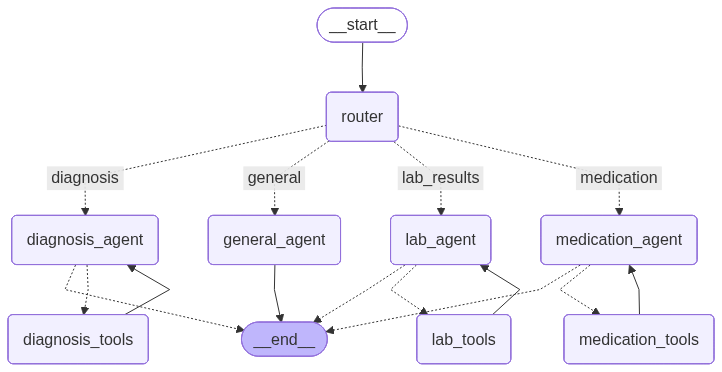

In [22]:
#BUILD, COMPILE AND VISUALIZE THE GRAPH

graph_builder = StateGraph(State)

#nodes
graph_builder.add_node("router", router)
graph_builder.add_node("medication_agent", medication_agent)
graph_builder.add_node("diagnosis_agent", diagnosis_agent)
graph_builder.add_node("lab_agent", lab_agent)
graph_builder.add_node("general_agent", general_agent)
graph_builder.add_node("medication_tools", medication_tool_node)
graph_builder.add_node("diagnosis_tools", diagnosis_tool_node)
graph_builder.add_node("lab_tools", lab_tool_node)

#start → router
graph_builder.add_edge(START, "router")

#router → specialist (based on domain)
graph_builder.add_conditional_edges(
    "router",
    route_to_agent,
    {
        "medication": "medication_agent",
        "diagnosis": "diagnosis_agent",
        "lab_results": "lab_agent",
        "general": "general_agent"
    }
)

#each specialist → its tools or END
graph_builder.add_conditional_edges("medication_agent", medication_should_continue,
    {"medication_tools": "medication_tools", END: END})
graph_builder.add_conditional_edges("diagnosis_agent", diagnosis_should_continue,
    {"diagnosis_tools": "diagnosis_tools", END: END})
graph_builder.add_conditional_edges("lab_agent", lab_should_continue,
    {"lab_tools": "lab_tools", END: END})

#general has no tools
graph_builder.add_edge("general_agent", END)

#tool results → back to agent (ReAct loop)
graph_builder.add_edge("medication_tools", "medication_agent")
graph_builder.add_edge("diagnosis_tools", "diagnosis_agent")
graph_builder.add_edge("lab_tools", "lab_agent")

graph = graph_builder.compile()
print("Graph compiled!")

#Visualize
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [23]:
#RUN AGENT

def run_agent(question: str):
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print(f"{'='*60}")
    
    events = graph.stream(
        {"messages": [HumanMessage(content=question)]},
        stream_mode="values"
    )
    
    for event in events:
        last_msg = event["messages"][-1]
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tc in last_msg.tool_calls:
                print(f"  🔧 Tool Call: {tc['name']}({tc['args']})")
        elif last_msg.type == "tool":
            print(f"  📋 Tool Result: {last_msg.content[:300]}")
        elif last_msg.type == "ai" and last_msg.content:
            print(f"  🤖 Response: {last_msg.content}")

In [24]:
#TESTS

run_agent("What are the side effects of warfarin?")
run_agent("My patient has chest pain and fatigue. What could it be?")
run_agent("My patient's glucose is 142 mg/dL. Is that normal?")
run_agent("Can a patient take warfarin and aspirin together?")
run_agent("What's the best way to stay healthy?")


Question: What are the side effects of warfarin?
🔀 Router classified as: medication
  🔧 Tool Call: drug_lookup({'drug_name': 'warfarin'})
  📋 Tool Result: Warfarin — Anticoagulant. Uses: blood clot prevention, atrial fibrillation. Side effects: bleeding, bruising.
  🤖 Response: Warfarin is an anticoagulant used to prevent blood clots and treat atrial fibrillation. Side effects include bleeding and bruising.

Question: My patient has chest pain and fatigue. What could it be?
🔀 Router classified as: diagnosis
  🔧 Tool Call: symptom_checker({'symptoms': 'chest pain, fatigue'})
  📋 Tool Result: Possible conditions: Myocardial Infarction (I21), Angina Pectoris (I20), GERD (K21), Anemia (D64.9), Hypothyroidism (E03), Depression (F32)
  🤖 Response: The patient's symptoms of chest pain and fatigue could be related to Myocardial Infarction (I21), Angina Pectoris (I20), GERD (K21), Anemia (D64.9), Hypothyroidism (E03), or Depression (F32). Would you like information on any of these conditions?
